<a href="https://colab.research.google.com/github/kishor-cypto/projects/blob/main/Skin_Cancer_Detection_Using_a_Spiking_Neural_Network_(SNN)_for_Binary_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install snntorch torchvision

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import torchvision.transforms as transforms

import snntorch as snn

from snntorch import spikegen
from snntorch import functional as SF

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

import os

In [38]:
transform = transforms.Compose([

    transforms.Grayscale(),

    transforms.Resize((32,32)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5,),
        (0.5,)
    )

])

In [39]:
class SkinCancerDataset(Dataset):

    def __init__(

        self,

        cancer_path,

        non_cancer_path,

        transform=None

    ):

        self.transform = transform

        self.images = []

        for img in os.listdir(cancer_path):

            self.images.append(

                (

                    os.path.join(
                        cancer_path,
                        img
                    ),

                    0

                )

            )

        for img in os.listdir(non_cancer_path):

            self.images.append(

                (

                    os.path.join(
                        non_cancer_path,
                        img
                    ),

                    1

                )

            )

    def __len__(self):

        return len(self.images)

    def __getitem__(self,idx):

        img_path,label = self.images[idx]

        image = Image.open(
            img_path
        ).convert("L")

        if self.transform:

            image = self.transform(
                image
            )

        return image,label

In [40]:
train_data = SkinCancerDataset(

    cancer_path="/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Cancer/Training",

    non_cancer_path="/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Non_Cancer/Training",

    transform=transform

)
test_data = SkinCancerDataset(

    cancer_path="/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Cancer/Testing",

    non_cancer_path="/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Non_Cancer/Testing",

    transform=transform

)

In [41]:
train_loader = DataLoader(

    train_data,

    batch_size=32,

    shuffle=True

)

test_loader = DataLoader(

    test_data,

    batch_size=32,

    shuffle=False

)

In [42]:
classes = [

    "Cancer",

    "Non_Cancer"

]

print(classes)

['Cancer', 'Non_Cancer']


In [43]:
num_steps = 50

beta = 0.9

epochs = 25

lr = 0.0005

In [44]:
class ImprovedSNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            16,
            3,
            padding=1
        )

        self.pool1 = nn.MaxPool2d(2)

        self.lif1 = snn.Leaky(
            beta=beta
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            3,
            padding=1
        )

        self.pool2 = nn.MaxPool2d(2)

        self.lif2 = snn.Leaky(
            beta=beta
        )

        self.conv3 = nn.Conv2d(
            32,
            64,
            3,
            padding=1
        )

        self.pool3 = nn.MaxPool2d(2)

        self.lif3 = snn.Leaky(
            beta=beta
        )

        self.fc1 = nn.Linear(
            64*4*4,
            2
        )

        self.lif4 = snn.Leaky(
            beta=beta
        )

    def forward(self,x):

        mem1 = self.lif1.init_leaky()

        mem2 = self.lif2.init_leaky()

        mem3 = self.lif3.init_leaky()

        mem4 = self.lif4.init_leaky()

        spk_out = []

        for t in range(num_steps):

            cur1 = self.pool1(
                self.conv1(
                    x[t]
                )
            )

            spk1,mem1 = self.lif1(
                cur1,
                mem1
            )

            cur2 = self.pool2(
                self.conv2(
                    spk1
                )
            )

            spk2,mem2 = self.lif2(
                cur2,
                mem2
            )

            cur3 = self.pool3(
                self.conv3(
                    spk2
                )
            )

            spk3,mem3 = self.lif3(
                cur3,
                mem3
            )

            cur4 = self.fc1(

                spk3.view(
                    spk3.size(0),
                    -1
                )

            )

            spk4,mem4 = self.lif4(
                cur4,
                mem4
            )

            spk_out.append(
                spk4
            )

        return torch.stack(
            spk_out
        )

In [45]:
model = ImprovedSNN().to(device)

print(model)

ImprovedSNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif1): Leaky()
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif2): Leaky()
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif3): Leaky()
  (fc1): Linear(in_features=1024, out_features=2, bias=True)
  (lif4): Leaky()
)


In [46]:
optimizer = optim.Adam(

    model.parameters(),

    lr=lr

)

In [47]:
loss_fn = SF.ce_rate_loss()

In [48]:
train_acc = []

test_acc = []

train_loss = []

test_loss = []

In [49]:
for epoch in range(epochs):

    # TRAIN

    model.train()

    correct = 0

    total = 0

    running_loss = 0

    for data,targets in train_loader:

        data = data.to(device)

        targets = targets.to(device)

        data = spikegen.rate(

            data,

            num_steps=num_steps

        )

        optimizer.zero_grad()

        spk_out = model(data)

        loss = loss_fn(

            spk_out,

            targets

        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pred = spk_out.sum(
            dim=0
        ).argmax(
            dim=1
        )

        correct += (

            pred==targets

        ).sum().item()

        total += targets.size(0)

    train_accuracy = 100*correct/total

    avg_train_loss = running_loss/len(train_loader)

    train_acc.append(
        train_accuracy
    )

    train_loss.append(
        avg_train_loss
    )

    # TEST

    model.eval()

    correct = 0

    total = 0

    running_loss = 0

    with torch.no_grad():

        for data,targets in test_loader:

            data = data.to(device)

            targets = targets.to(device)

            data = spikegen.rate(

                data,

                num_steps=num_steps

            )

            spk_out = model(data)

            loss = loss_fn(

                spk_out,

                targets

            )

            running_loss += loss.item()

            pred = spk_out.sum(
                dim=0
            ).argmax(
                dim=1
            )

            correct += (

                pred==targets

            ).sum().item()

            total += targets.size(0)

    testing_accuracy = 100*correct/total

    avg_test_loss = running_loss/len(test_loader)

    test_acc.append(
        testing_accuracy
    )

    test_loss.append(
        avg_test_loss
    )

    print(

        f"Epoch {epoch+1}/{epochs} | "

        f"Train Acc: {train_accuracy:.2f}% | "

        f"Test Acc: {testing_accuracy:.2f}% | "

        f"Train Loss: {avg_train_loss:.4f} | "

        f"Test Loss: {avg_test_loss:.4f}"

    )

Epoch 1/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 2/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 3/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 4/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 5/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 6/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 7/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 8/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 9/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 10/25 | Train Acc: 50.00% | Test Acc: 20.59% | Train Loss: 0.6931 | Test Loss: 0.6931
Epoch 11/25 | Train Acc: 51.19% | Test Acc: 47.55% | Train Loss: 0.6931 | Test Loss: 0.68

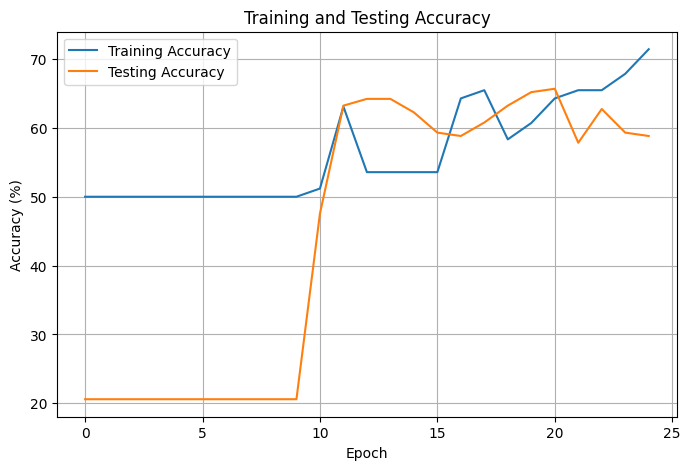

In [50]:
plt.figure(figsize=(8,5))

plt.plot(train_acc,label="Training Accuracy")

plt.plot(test_acc,label="Testing Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training and Testing Accuracy")

plt.legend()

plt.grid(True)

plt.show()

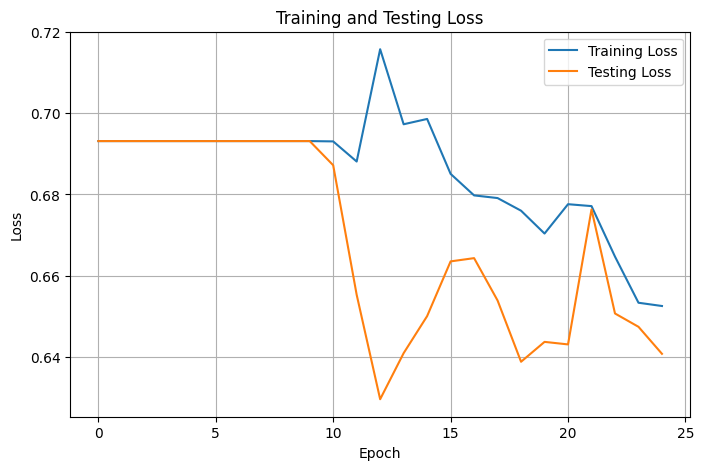

In [51]:
plt.figure(figsize=(8,5))

plt.plot(train_loss,label="Training Loss")

plt.plot(test_loss,label="Testing Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Testing Loss")

plt.legend()

plt.grid(True)

plt.show()

In [52]:
model.eval()

correct = 0

total = 0

all_preds = []

all_targets = []

with torch.no_grad():

    for data,targets in test_loader:

        data = data.to(device)

        targets = targets.to(device)

        data = spikegen.rate(
            data,
            num_steps=num_steps
        )

        spk_out = model(data)

        pred = spk_out.sum(
            dim=0
        ).argmax(
            dim=1
        )

        correct += (
            pred==targets
        ).sum().item()

        total += targets.size(0)

        all_preds.extend(
            pred.cpu().numpy()
        )

        all_targets.extend(
            targets.cpu().numpy()
        )

accuracy = 100*correct/total

print("Test Accuracy: {:.2f}%".format(accuracy))

Test Accuracy: 58.33%


In [53]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import seaborn as sns

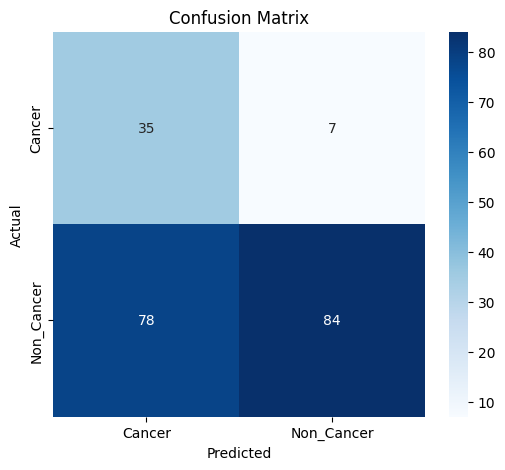

In [54]:
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [55]:
print(

    classification_report(

        all_targets,

        all_preds,

        target_names=classes

    )

)

              precision    recall  f1-score   support

      Cancer       0.31      0.83      0.45        42
  Non_Cancer       0.92      0.52      0.66       162

    accuracy                           0.58       204
   macro avg       0.62      0.68      0.56       204
weighted avg       0.80      0.58      0.62       204



In [56]:
f1 = f1_score(

    all_targets,

    all_preds,

    average="weighted"

)

print()

print("F1 Score:",f1)


F1 Score: 0.6202983552212165


In [57]:
all_scores = []

model.eval()

with torch.no_grad():

    for data,targets in test_loader:

        data = data.to(device)

        data = spikegen.rate(
            data,
            num_steps=num_steps
        )

        spk_out = model(data)

        scores = spk_out.sum(
            dim=0
        )

        probs = torch.softmax(
            scores,
            dim=1
        )

        all_scores.extend(

            probs[:,1].cpu().numpy()

        )

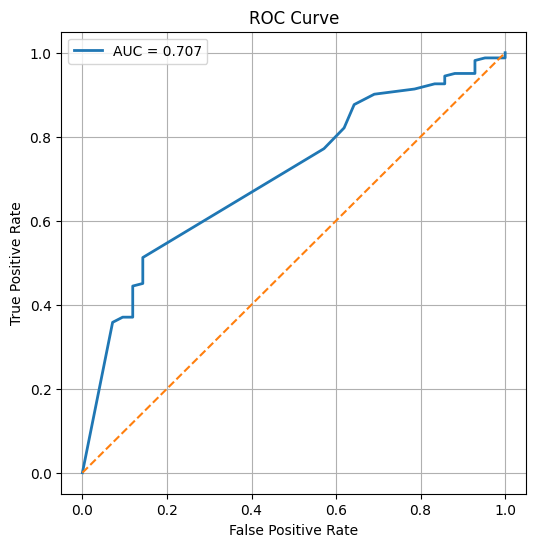


AUC Score: 0.7070840681951792


In [58]:
fpr,tpr,thresholds = roc_curve(

    all_targets,

    all_scores

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label="AUC = %0.3f"%roc_auc

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

print()

print("AUC Score:",roc_auc)

In [59]:
from google.colab import files

uploaded = files.upload()

Saving 1811-3.JPG to 1811-3 (1).JPG


In [60]:
def predict_image(path):

    img = Image.open(
        path
    ).convert("L")

    img = transform(
        img
    )

    img = img.unsqueeze(
        0
    ).to(device)

    img = spikegen.rate(

        img,

        num_steps=num_steps

    )

    with torch.no_grad():

        spk_out = model(
            img
        )

        pred = spk_out.sum(
            dim=0
        ).argmax(
            dim=1
        )

    return classes[
        pred.item()
    ]

In [61]:
for file in uploaded.keys():

    print()

    print(

        "Prediction:",

        predict_image(file)

    )


Prediction: Cancer
